In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load preprocessed data
df_model = pd.read_csv('df_preprocessed.csv')
df_model['Flight_Date'] = pd.to_datetime(df_model['Flight_Date'], errors='coerce')
df_model['Month'] = df_model['Flight_Date'].dt.month
# Define features and target variables
categorical_cols = [
    'Destination',
    'Aircraft_Type',
    'Season',
    'Route_Category',
    'Demand_Level'
]

numeric_cols = [
    'Aircraft_Capacity',
    'Load_Factor',
    'Flight_Hours',
    'Month',
    'Ancillary_Revenue_was_missing',
    'Catering_Cost_was_missing',
    'Handling_Cost_was_missing'
]

X = df_model[categorical_cols + numeric_cols]

# Direct target
y_margin = df_model['Profit_Margin']

# Indirect targets
y_revenue = df_model['Total_Revenue']
y_cost = df_model['Total_Cost']

In [84]:
# One-hot encoding pipeline
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop=None, sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ],
    remainder='drop'
)

# Fit-transform example
X_encoded = preprocessor.fit_transform(X)

# Get encoded feature names
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = list(encoded_cat_names) + numeric_cols

# Convert back to DataFrame for inspection
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names, index=X.index)

print("Modeling dataframe shape:", df_model.shape)
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded_df.shape)
print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Modeling dataframe shape: (7974, 42)
Original X shape: (7974, 12)
Encoded X shape: (7974, 52)

Categorical columns: ['Destination', 'Aircraft_Type', 'Season', 'Route_Category', 'Demand_Level']
Numeric columns: ['Aircraft_Capacity', 'Load_Factor', 'Flight_Hours', 'Month', 'Ancillary_Revenue_was_missing', 'Catering_Cost_was_missing', 'Handling_Cost_was_missing']


In [85]:
# Split dataset
X_train, X_test, y_margin_train, y_margin_test, y_revenue_train, y_revenue_test, y_cost_train, y_cost_test = train_test_split(
    X, y_margin, y_revenue, y_cost,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (6379, 12)
Test shape : (1595, 12)


In [86]:
# PREPROCESSORS
# For LR: scaled features
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='drop'
)
# For tree-based models, skip scaling
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ],
    remainder='drop'
)

In [87]:
# Evaluation helper + Pipeline helper
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

def make_pipeline(preprocessor, estimator):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', clone(estimator))
    ])

### Model training and evaluation

Define Models

In [88]:
model_registry = {
    'LinearRegression': {
        'preprocessor': preprocessor_scaled,
        'estimator': LinearRegression()
    },
    'RandomForest': {
        'preprocessor': preprocessor_unscaled,
        'estimator': RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    },
    'XGBoost': {
        'preprocessor': preprocessor_unscaled,
        'estimator': XGBRegressor(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }
}

print("Models configured:", list(model_registry.keys()))

Models configured: ['LinearRegression', 'RandomForest', 'XGBoost']


Train all models (both Direct & Indirect)

In [89]:
results = []
fitted_models = {}

for model_name, cfg in model_registry.items():
    print(f"Running {model_name}...")

    preprocessor = cfg['preprocessor']
    estimator = cfg['estimator']

    # -------------------------
    # Direct model: predict Profit_Margin directly
    # -------------------------
    direct_margin_model = make_pipeline(preprocessor, estimator)
    direct_margin_model.fit(X_train, y_margin_train)
    y_margin_pred_direct = direct_margin_model.predict(X_test)

    direct_metrics = regression_metrics(y_margin_test, y_margin_pred_direct)

    # -------------------------
    # Indirect models: predict Revenue and Cost separately
    # -------------------------
    revenue_model = make_pipeline(preprocessor, estimator)
    cost_model = make_pipeline(preprocessor, estimator)

    revenue_model.fit(X_train, y_revenue_train)
    cost_model.fit(X_train, y_cost_train)

    y_revenue_pred = revenue_model.predict(X_test)
    y_cost_pred = cost_model.predict(X_test)

    # Reconstruct margin from predicted revenue and cost
    # Clip unreasonable revenue predictions to avoid unstable ratios
    revenue_floor = np.percentile(y_revenue_train, 1)
    y_revenue_pred_safe = np.maximum(y_revenue_pred, revenue_floor)

    y_margin_pred_indirect = ((y_revenue_pred - y_cost_pred) / y_revenue_pred_safe) * 100

    indirect_metrics = regression_metrics(y_margin_test, y_margin_pred_indirect)
    revenue_metrics = regression_metrics(y_revenue_test, y_revenue_pred)
    cost_metrics = regression_metrics(y_cost_test, y_cost_pred)

    results.append({
        'Model': model_name,
        'Direct_RMSE': direct_metrics['RMSE'],
        'Direct_MAE': direct_metrics['MAE'],
        'Direct_R2': direct_metrics['R2'],
        'Indirect_RMSE': indirect_metrics['RMSE'],
        'Indirect_MAE': indirect_metrics['MAE'],
        'Indirect_R2': indirect_metrics['R2'],
        'Revenue_RMSE': revenue_metrics['RMSE'],
        'Revenue_MAE': revenue_metrics['MAE'],
        'Revenue_R2': revenue_metrics['R2'],
        'Cost_RMSE': cost_metrics['RMSE'],
        'Cost_MAE': cost_metrics['MAE'],
        'Cost_R2': cost_metrics['R2']
    })

    fitted_models[model_name] = {
        'direct_margin_model': direct_margin_model,
        'revenue_model': revenue_model,
        'cost_model': cost_model,
        'y_margin_pred_direct': y_margin_pred_direct,
        'y_margin_pred_indirect': y_margin_pred_indirect,
        'y_revenue_pred': y_revenue_pred,
        'y_cost_pred': y_cost_pred
    }

Running LinearRegression...
Running RandomForest...
Running XGBoost...


In [90]:
results_df = pd.DataFrame(results)

results_df['Better_Approach'] = np.where(
    results_df['Direct_RMSE'] < results_df['Indirect_RMSE'],
    'Direct',
    'Indirect'
)

results_df = results_df.sort_values('Direct_RMSE').reset_index(drop=True)

results_df

,Model,Direct_RMSE,Direct_MAE,Direct_R2,Indirect_RMSE,Indirect_MAE,Indirect_R2,Revenue_RMSE,Revenue_MAE,Revenue_R2,Cost_RMSE,Cost_MAE,Cost_R2,Better_Approach
0,LinearRegression,21.158250,16.028107,0.697927,63.264166,33.223846,-1.700650,96808.448233,68720.517428,0.865451,26560.401647,18958.054974,0.976715,Direct
1,XGBoost,21.512836,16.013749,0.687717,21.749188,15.914265,0.680818,92730.057352,59457.894344,0.876549,21663.952247,13914.247329,0.984509,Direct
2,RandomForest,22.226147,16.464830,0.666665,22.609724,16.277137,0.655060,95220.840787,60767.189756,0.869828,22603.141085,14549.896787,0.983137,Direct


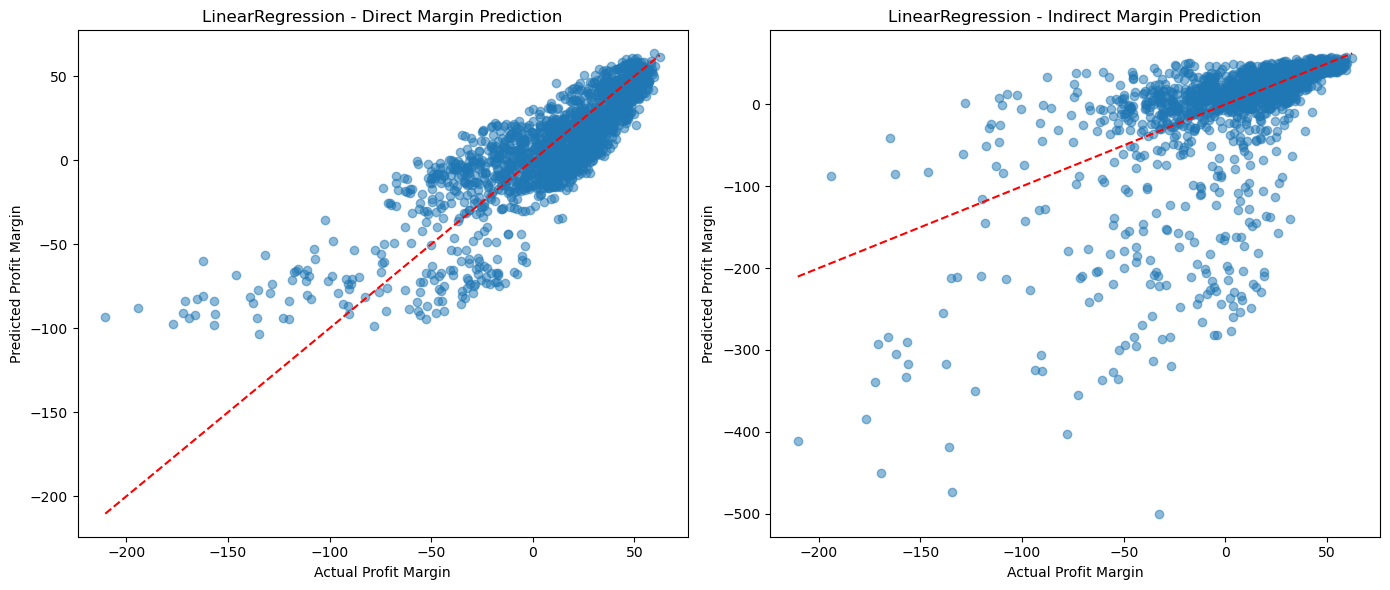

In [91]:
best_model_name = results_df.iloc[0]['Model']
best_preds = fitted_models[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_margin_test, best_preds['y_margin_pred_direct'], alpha=0.5)
axes[0].plot(
    [y_margin_test.min(), y_margin_test.max()],
    [y_margin_test.min(), y_margin_test.max()],
    'r--'
)
axes[0].set_title(f'{best_model_name} - Direct Margin Prediction')
axes[0].set_xlabel('Actual Profit Margin')
axes[0].set_ylabel('Predicted Profit Margin')

axes[1].scatter(y_margin_test, best_preds['y_margin_pred_indirect'], alpha=0.5)
axes[1].plot(
    [y_margin_test.min(), y_margin_test.max()],
    [y_margin_test.min(), y_margin_test.max()],
    'r--'
)
axes[1].set_title(f'{best_model_name} - Indirect Margin Prediction')
axes[1].set_xlabel('Actual Profit Margin')
axes[1].set_ylabel('Predicted Profit Margin')

plt.tight_layout()
plt.show()

1. Direct prediction is the most accurate overall: For all tested models, predicting 'Profit_Margin' directly gives lower error than reconstructing it from separately predicted revenue and cost.

2. The gap depends on model class:
- For Linear Regression, indirect prediction is much worse.
- For tree-based models, especially XGBoost, indirect prediction is quite competitive.

3. The indirect approach still has value: Even though it loses slightly on RMSE, the indirect approach remains useful because by modelling Revenue and Cost separately it gives more business insight, helps explain why margin changes

## Explainability 

For the **direct approach**, Linear Regression achieved the best performance in predicting `Profit_Margin`. Because Linear Regression is inherently interpretable, the direct model is explained using its regression coefficients. 

For the **indirect approach**, Linear Regression performed substantially worse after reconstructing profit margin from separately predicted revenue and cost. Therefore, the component-based explainability analysis focuses on the stronger nonlinear model, XGBoost. SHAP (SHapley Additive exPlanations) is used to interpret the XGBoost revenue and cost models, making it possible to compare the key drivers of the two financial components.

In [92]:
# Direct approach explainability: Linear Regression coefficients
lin_direct_pipe = fitted_models['LinearRegression']['direct_margin_model']
lin_preprocessor = lin_direct_pipe.named_steps['preprocessor']
lin_model = lin_direct_pipe.named_steps['model']

lin_feature_names = lin_preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': lin_feature_names,
    'Coefficient': lin_model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Top coefficients in the direct Linear Regression profit margin model:")
display(coef_df.head(20))

Top coefficients in the direct Linear Regression profit margin model:


,Feature,Coefficient,Abs_Coefficient
0,cat__Route_Category_Short Haul,-85.060365,85.060365
1,cat__Destination_BKK,36.614611,36.614611
2,cat__Destination_LHR,-36.549771,36.549771
3,cat__Destination_KUL,33.816957,33.816957
4,cat__Destination_JED,-22.777547,22.777547
5,cat__Demand_Level_Medium,-20.112126,20.112126
6,cat__Destination_LHE,19.765588,19.765588
7,cat__Destination_MCT,17.775736,17.775736
8,cat__Aircraft_Type_Boeing 787-9,-16.891743,16.891743
9,cat__Destination_BAH,15.239088,15.239088


- Route_Category_Short Haul = -85.06 -> Short-haul weakness is structural, not just temporary underperformance.
- Some destinations have positive effect, other have negative, this can be explained by different load factor, routes with less competitive, lower cost structure, suitable route–aircraft matching,..
- Negative effects of Boeing 787-9 or Airbus 350-900 don't mean these aircraft types are bad, these appear to be deployment-dependent rather than purely aircraft-dependent.
- Aircraft_Capacity = -13.95 -> Capacity expansion without sufficient demand quality may dilute profitability.

In [93]:
# Get fitted XGBoost pipelines
xgb_direct_pipe = fitted_models['XGBoost']['direct_margin_model']
xgb_revenue_pipe = fitted_models['XGBoost']['revenue_model']
xgb_cost_pipe = fitted_models['XGBoost']['cost_model']

# Transform X-test once
xgb_preprocessor = xgb_direct_pipe.named_steps['preprocessor']
X_test_transformed = xgb_preprocessor.transform(X_test)
feature_names = xgb_preprocessor.get_feature_names_out()

if sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19776\2524434591.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_direct, X_test_transformed_df, show=False)


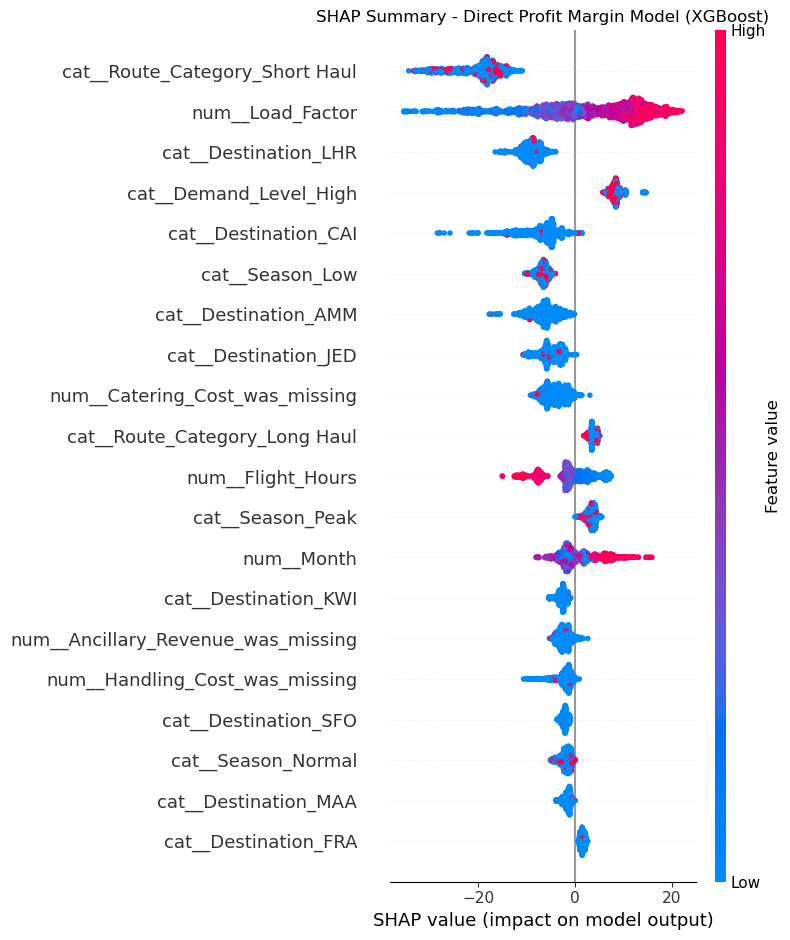

In [94]:
# Direct margin SHAP
xgb_direct_model = xgb_direct_pipe.named_steps['model']

explainer_direct = shap.TreeExplainer(xgb_direct_model)
shap_values_direct = explainer_direct.shap_values(X_test_transformed_df)

plt.figure()
shap.summary_plot(shap_values_direct, X_test_transformed_df, show=False)
plt.title("SHAP Summary - Direct Profit Margin Model (XGBoost)")
plt.tight_layout()
plt.show()

Margin is a mixed outcome driven jointly by commercial strength (demand level, load factor) and operating structure (longer flying time / certain route profiles).

C:\Users\Admin\AppData\Local\Temp\ipykernel_19776\3428050626.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_revenue, X_test_transformed_df, show=False)


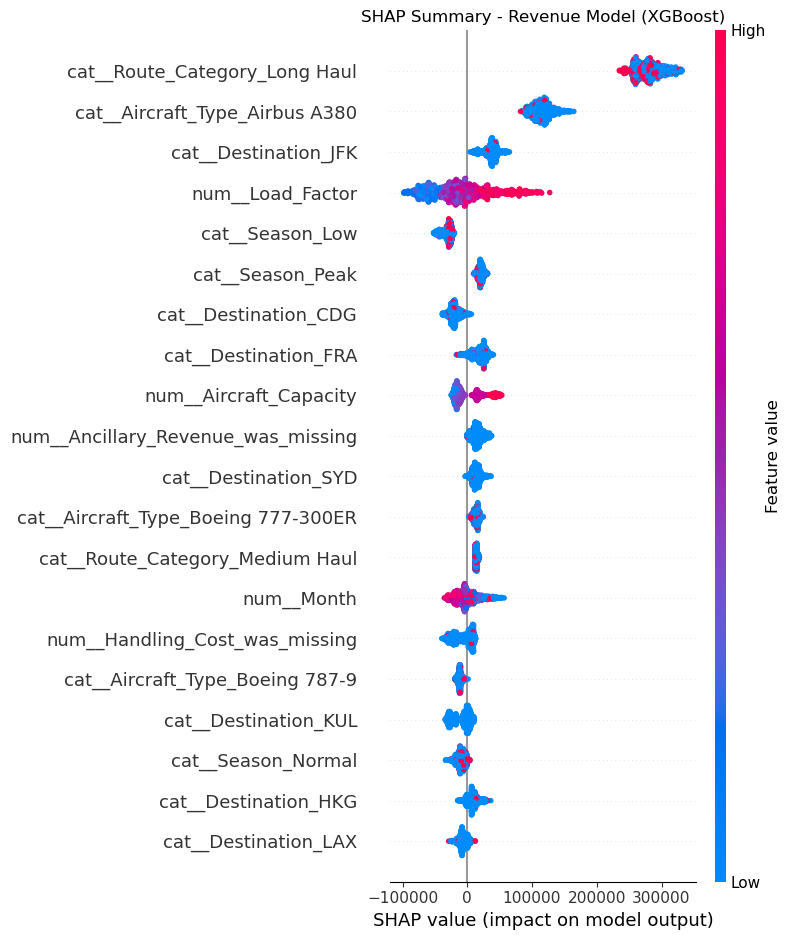

In [95]:
# Revenue model
xgb_revenue_model = xgb_revenue_pipe.named_steps['model']

explainer_revenue = shap.TreeExplainer(xgb_revenue_model)
shap_values_revenue = explainer_revenue.shap_values(X_test_transformed_df)

plt.figure()
shap.summary_plot(shap_values_revenue, X_test_transformed_df, show=False)
plt.title("SHAP Summary - Revenue Model (XGBoost)")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19776\3698798745.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_cost, X_test_transformed_df, show=False)


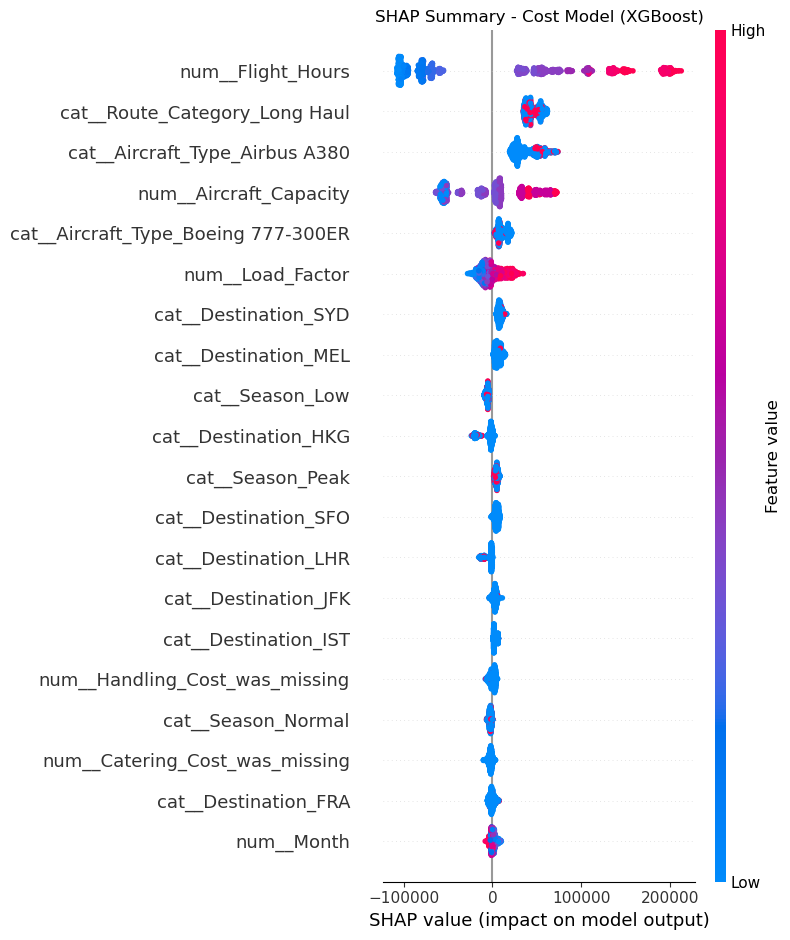

In [96]:
# Cost model
xgb_cost_model = xgb_cost_pipe.named_steps['model']

explainer_cost = shap.TreeExplainer(xgb_cost_model)
shap_values_cost = explainer_cost.shap_values(X_test_transformed_df)

plt.figure()
shap.summary_plot(shap_values_cost, X_test_transformed_df, show=False)
plt.title("SHAP Summary - Cost Model (XGBoost)")
plt.tight_layout()
plt.show()

-> Revenue and cost are driven by different mechanisms.

Revenue side looks more commercial / network-market driven, heavily drived by:
- long-haul premium network structure
- destination economics
- load factor
- aircraft deployment on high-yield routes

This means revenue reflects:
- demand quality
- route attractiveness
- pricing power
- commercial positioning

Cost side looks more operational / physical-production driven, specifically by:
- flight hours
- aircraft size
- long-haul structure
- capacity

This mean cost reflects:
- block time
- asset intensity
- operating scale
- resource consumption